# Changing Slope and Shape of Term Structure

This analysis builds upon previous work presented in two notebooks of this chapter:

1.  *Illustrating the Effects with Parallel Shifts in Yields to Maturity*  exploring the effect of convexity on bond prices assuming identical or parallel changes in interest rates
2.   *Changes in Par Yields Between 1993 and 2025* demonstrates that parallel shifts in interest rates are uncommon.


This notebook extends the investigation by examining two convexity-focused trades. The trades are demonstrated using U.S. Treasury par yield data.$^{1}$ In one case, parallel changes are assumed; in the other,  non-parallel changes.

The keys of the trade are a long convexity position and zero duration. The results for parallel shifts are perfectly predictable. Non-parallel changes alter the slope and shape of the term structure making the results unpredictable. The point is demonstrated by simulating parallel and non-parallel changes in yields to maturity.

The simulations are conducted with a new module from the **scipy** library—specifically, the **stats** module. The analysis considers three distinct levels of uncertainty for both the parallel and non-parallel yield change scenarios.  All simulations follow the *Beta* distributions that allow for variations in the shape of the probability density function and the range of outcomes. Our analysis assumes that:



*   The distributions are centered around zero.
*   The least uncertainty is generated from distributions highly peaked around zero, and the greatest uncertainty results from distributions that are flat over the range of outcomes.

The distributions are meant to illustrate how changes in the shape and slope of the term structures result in fuzzy predictions based on duration and convexity.  The message isn't that bond math should be ignored; rather, its use requires judgement.


---


$^{1}$Prior notebooks have used FRED for par yield data. The change to U.S. Treasury data is intended to illustrate an alternative. The data are identical.


## Preparing the notebook

### Importing libraries, modules, and functions
As in earlier chapters of the volume, modules that are included in the standard Python library are imported. When necessary, other modules or libraries are installed before they are imported.$^{2}$  Because pandas_data_reader and scipy are not part of the Pandas library, they are imported and when necessary installed.

```
import sys
import requests
from types import ModuleType
from datetime import datetime, date

try:
    import numpy as np
except:
    !pip install numpy
    import numpy as np

try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd
from pandas import describe_option

try:
    from scipy.stats import beta
except:
    !pip install scipy
    from scipy.stats import beta    
```
---

$^{2}$For more information on <font color='green'>try</font> and <font color='green'>except</font> statements, see “<a href='https://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/Control_Statements.html#the-try-and-except'>Control Statements</a>.”

In [1]:
import os
import sys
import requests
from types import ModuleType
from datetime import datetime, date
from dateutil.relativedelta import relativedelta
try:
    import numpy as np
except:
    !pip install numpy
    import numpy as np
try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd
from pandas import describe_option

# the new module from the scipy library
try:
    from scipy.stats import beta
except:
    !pip install scipy
    from scipy.stats import beta

### Adding a custom module and importing functions
The <font color='green'>module_basic_concepts_fixed_income</font> custom module contains functions utilized in the notebooks within the "Basic Concepts of Fixed Income" volume. This module is accessed from Dropbox using <font color='green'>requests</font>.
You have the flexibility to choose the module name; in this instance,  <font color='green'>basic_concepts_fixed_income</font> is assigned to <font color='green'>module_name</font>. The module is instantiated with <font color='green'>ModuleType</font> using the chosen <font color='green'>module_name</font>. Once created, the module becomes accessible in the notebook's memory, though it is not added to a drive.
```
url= 'https://www.dropbox.com/scl/fi/4y5hjxlfphh1ngvbgo77q/\
module_-basic_concepts_fixed_income.py?rlkey=6oxi7mgka42veaat79hcv8boz&st=stuou11h&dl=1'
module_name='module_basic_concepts_fixed_income'
try:
  response=requests.get(url)
  module=ModuleType(module_name)

```
The <font color='green'>exec</font> function executes the Python code returned by <font color='green'>request.get</font>. It assigns functions and variables to <font color='green'>sys.module[module_name]</font>, making the module available to the notebook.
```
exec(response.text,module.__dict__)
sys.module[module_name]=module
```
Five functions are imported from the module:


```
from basic_concepts_fixed_income import(bond_pay_data,
                                        bond_pv,
                                        calc_duration,
                                        calc_convexity,
                                        one_y_axis)
```

* **bond_pay_data** ([Chapter Three](https://patrickjhess.github.io/Vol-3-Chap-2-Chap-3/Bond_Pay_Dates.html#bond-payment-dates)): Returns the payment dates and amounts.  
  * [View Details](https://patrickjhess.github.io/Imported-Functions/bond_pay_data.html#bond-pay-data-helper-function)


* **bond_pv** ([Chapter Six](https://patrickjhess.github.io/Vol-3-Chap-6/Calculating_Yields_To_Maturity.html#demonstrating-bond-pv)): Returns the present value of a bond.  
  * [View Details](https://patrickjhess.github.io/Imported-Functions/bond_pv.html)

* **calc_duration**  ([Chapter Seven](https://patrickjhess.github.io/Vol-3-Chap-7/Measuring_Interest_Rate_Risk_With_Duration.html#demonstrating-the-calc-duration-with-304-fidelity-bonds) Calculates duration
    * [View Details](https://patrickjhess.github.io/Imported-Functions/calc_duration.html)

* **calc_convexity** (Chapter Eight): Calculates convexity
    * [View Details](https://patrickjhess.github.io/Imported-Functions/calc_convexity.html#)

* **one_y_axis** ([Chapter One](https://patrickjhess.github.io/Vol-3-Chap-1/Calculating_And_Graphing_The_Term_Structure_Of_Interest_Rates.html#graphing-the-spot-and-forward-rates-for-september-15-2022)): Plots multiple series against a single x axis.

  * [View Details](https://patrickjhess.github.io/Imported-Functions/one_y_axis.html)



In [2]:
# Define the URL of the Python module to be downloaded from Dropbox.
# The 'dl=1' parameter in the URL forces a direct download of the file content.
url= 'https://www.dropbox.com/scl/fi/4y5hjxlfphh1ngvbgo77q/\
module_-basic_concepts_fixed_income.py?rlkey=6oxi7mgka42veaat79hcv8boz&st=stuou11h&dl=1'
module_name='basic_concepts_fixed_income'
# Send an HTTP GET request to the URL and store the server's response.
try:
  response=requests.get(url)
  # Raise an exception for bad status codes (like 404 Not Found)
  response.raise_for_status()
  module= ModuleType(module_name)
  #Code contained in response.text executed
  exec(response.text, module.__dict__)
  # Module added to sys
  sys.modules[module_name]=module
except requests.exceptions.RequestException as e:
    print(f"❌ Error: Could not fetch module from URL. {e}")
except Exception as e:
    print(f"❌ Error: Failed to execute or import the module. {e}")
# Open the local file in "write binary" ('wb') mode and save the downloaded content.
# Using a 'with' statement ensures the file is properly closed after writing.

# Now that 'basic_concepts_fixed_income' exists in the notebook, import the specific functions
from basic_concepts_fixed_income import(bond_pay_data,
                                        bond_pv,
                                        calc_duration,
                                        calc_convexity,
                                        one_y_axis)

## Using par yield data to demonstrate convexity

As in Chapter Five, par yield data is accessed from the U.S. Treasury for 2026.  The data is returned as a CSV file and the Pandas method <font color='green'>read_csv</font> returns a DataFrame.


```
# url address for daily par yields in 2026
url='https://home.treasury.gov/resource-center/data-chart-center/interest-rates/\
daily-treasury-rates.csv/2026/all?field_tdr_date_value=2026\
&type=daily_treasury_yield_curve&page&_format=csv'

# pandas method read_csv creates the DataFrame, parse_dates converts strings to datetimes
us_treasury_par=pd.read_csv(url,index_col='Date',parse_dates=True)
#display to confirm DataFrame creation
display(us_treasury_par.iloc[:5])

```




In [3]:
# url address for daily par yields in 2026
url='https://home.treasury.gov/resource-center/data-chart-center/interest-rates/\
daily-treasury-rates.csv/2026/all?field_tdr_date_value=2026\
&type=daily_treasury_yield_curve&page&_format=csv'

# pandas method read_csv creates the DataFrame, parse_dates converts string to datetimes
us_treasury_par=pd.read_csv(url,index_col='Date',parse_dates=True)

# display to confirm DataFrame creation
display(us_treasury_par.iloc[:5])

,1 Mo,1.5 Month,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
Date,,,,,,,,,,,,,,
2026-03-17,3.74,3.72,3.72,3.72,3.69,3.71,3.63,3.68,3.68,3.79,3.98,4.20,4.81,4.85
2026-03-16,3.75,3.73,3.72,3.72,3.69,3.72,3.64,3.68,3.69,3.80,4.00,4.23,4.83,4.86
2026-03-13,3.75,3.74,3.71,3.72,3.69,3.70,3.66,3.73,3.74,3.87,4.07,4.28,4.89,4.90
2026-03-12,3.76,3.74,3.72,3.72,3.69,3.70,3.66,3.76,3.75,3.88,4.06,4.27,4.86,4.88
2026-03-11,3.75,3.73,3.70,3.71,3.69,3.68,3.60,3.64,3.64,3.79,3.98,4.21,4.82,4.86


## Create a DataFrame of par yields maturities six or more months for February 3$^{rd}$ 2026.


*   Use the <font color='green'>columns</font> attribute to exclude maturities less six months.

*   Get the desired data with <font color='green'>loc</font> attribute of selected date and maturities with row and columns.
    * row: '2026-02-03'
    * columns: <font color='green'>select_maturities</font>


*   Use Pandas function <font color='green'>DateOffset</font> to determine maturity dates relative to the assumed date of February 3$^{rd}$ 2026.$^{3}$

*   Create <font color='green'>par_yield_data</font> from the values of <font color='green'>feb_3_2026_par_yields</font> and the calculated maturity dates.



---
$^{3}$ For more information on <font color='green'>DateOffset</font> see “<a href='https://patrickjhess.github.io/Introduction-To-Python-For-Financial-Python/DateOffset"'>Date Offset</a> in Background Material. <font color='green'>NOT COMPLETED!!</font>

In [4]:
# get columns (maturity dates of par yields) for 6 months to 30 years
select_maturities = [maturity for maturity in us_treasury_par.columns
                     if '6 Mo' in maturity or 'Yr' in maturity]

# This returns a DataFrame because select_maturities is a list
feb_3_2026_par_yields = us_treasury_par.loc[['2026-02-03'], select_maturities]

# FIX: Use .index[0] instead of .name
current_date = feb_3_2026_par_yields.index[0]

# Calculate offsets (logic remains the same)
offset_months = [int(value.split()[0]) * 12 if 'Mo' not in value else 6
                 for value in select_maturities]

# Create the specific maturity dates
maturities = [current_date + pd.DateOffset(months=num_months) for num_months in offset_months]

# create a DataFrame - flatten the values since feb_3_2026_par_yields is 2D
par_yield_data = pd.DataFrame({'Par Yields': feb_3_2026_par_yields.values.flatten()},
                              index=maturities)

display(par_yield_data)

,Par Yields
2026-08-03,3.62
2027-02-03,3.49
2028-02-03,3.57
2029-02-03,3.64
2031-02-03,3.83
2033-02-03,4.04
2036-02-03,4.28
2046-02-03,4.85
2056-02-03,4.90


## Calculate the convexity and duration with par yields

The convexity and duration for each bond is calculated with the imported functions:



*   **Convexity**: <font color='green'>calc_convexity</font>
*   **Duration**: <font color='green'>calc_duration</font>

The yield to maturity of the bonds are inferred from their coupons and their price of 100.

In [5]:
# this is the date that the bond math (time to maturity) is calculated from.
settlement = date(2026, 2, 3)

# create empty lists to hold the calculated values for every bond in the loop.
convexities = []
durations = []

# zip the dataframe's index (Maturity Dates) and values (Coupons)
# to access both properties simultaneously for each row.
for maturity, coupon in zip(par_yield_data.index, par_yield_data.values):

  # calculate Convexity
  # calls the custom 'calc_convexity' function using the bond's specific maturity and coupon.
  # assumes a par price of 100. result is rounded to 3 decimal places.
  convexities.append(round(calc_convexity(maturity, coupon, price=100,
                                          settlement=settlement), 3))

  # calculate Duration
  # calls the custom 'calc_duration' function for the same bond rounded to 3 decimal places.
  # result is rounded to 3 decimal places.
  durations.append(round(calc_duration(maturity, coupon, price=100,
                                       settlement=settlement), 3))

# assign the lists as new columns to the existing 'par_yield_data' DataFrame.
par_yield_data['Convexity'] = convexities
par_yield_data['Duration'] = durations

# display the DataFrame to verify the new columns have been added correctly.
display(par_yield_data)

,Par Yields,Convexity,Duration
2026-08-03,3.62,0.246,0.496
2027-02-03,3.49,0.986,0.991
2028-02-03,3.57,3.847,1.947
2029-02-03,3.64,8.489,2.874
2031-02-03,3.83,22.264,4.597
2033-02-03,4.04,41.171,6.167
2036-02-03,4.28,76.619,8.239
2046-02-03,4.85,219.498,13.020
2056-02-03,4.90,368.043,16.014


## The relation between duration and convexity

The six-month maturity bond is noteworthy because it is assumed to have a single payment, meaning its convexity is simply equal to the square of its duration. In contrast, bonds that are assumed to make interim payments will have convexities that are greater than the squared value of their durations.


## Two hypothetical long convexity zero duration trades

This notebook details two distinct bond trading strategies. Both involve taking a long position in a thirty-year bond and hedging it with a short position in either a twenty-year or a ten-year bond. This approach is designed to neutralize the impact of parallel shifts in interest rates, allowing the trade to profit from volatility. The position does not, however, perfectly hedge against changes in the yield curve's slope or shape. In contrast to the notebook that demonstrated the convexity effect with a parallel yield shift (*Illustrating The Effects With Parallel Shifts In Yields To Maturity*), the par yield bonds are priced at their par values of 100 allowing the hedge ratios to be solely determined by the ratios of durations.

**Trade 1: Long 30-Year, Short 20-Year**

This trade involves a long position of one thirty-year bond and a short position of 1.23 twenty-year bonds. The 1:1.23 long-short ratio is selected to achieve a zero-duration position while maximizing positive convexity:


<br>

* **Duration**: $0 = 16.014 -1.23\times 13.02$  
* **Convexity**:  $98.07 = 368.043 -1.23\times 219.498$

<br>

**Trade 2: Long 30-Year, Short 10-Year**


The second trade pairs a long position of one thirty-year bond with a short position of 1.94 ten-year bonds. Similar to Trade 1, this 1:1.94 hedge ratio results in zero duration but achieves a significantly higher convexity:

<br>

* **Duration**:  $0 = 16.014 - 1.94\times 8.239$   
* **Convexity**: $219.12 = 368.043 -1.94\times 76.619$
<br>



## Get preliminary data for ten, twenty, and thirty year bonds selling for par yield.




*   **Settlement Date**: February 3$^{3}$ 2026
*   **Maturity Dates**:
      * Settlement date plus ten years <font color='green'>date(2036,2,3)</font>
      * Settlement date plus twenty years <font color='green'>date(2046,2,3)</font>
      * Settlement date plus thirty years <font color='green'>date(2056,2,3)</font>
*  **Hedge Ratios (short position)**:
      * ten-year hedge ratio is 1.94  <font color=green>$\Large(\frac{duration_{30}}{duration_{10}})$</font>
      
     * twenty-year hedge ratio is 1.23 <font color=green>$\Large(\frac{duration_{30}}{duration_{20}})$</font>
*   **Continuous Yields to Maturity**:
      * ten-year yield to maturity <font color='green'>2*np.log(1+coupon_10/200)</font>
     * twenty-year yield to maturity <font color='green'>2*np.log(1+coupon_20/200)</font>
     * thirty-year yield to maturity <font color='green'>2*np.log(1+coupon_30/200)</font>
   



In [6]:
# assumed settlement date
settlement=date(2026,2,3)

# maturity dates
maturity_10=date(2036,2,3)
maturity_20=date(2046,2,3)
maturity_30=date(2056,2,3)

# get coupon rates with row and column value of loc
coupon_10=par_yield_data.loc['2036-02-03','Par Yields']
coupon_20=par_yield_data.loc['2046-02-03','Par Yields']
coupon_30=par_yield_data.loc['2056-02-03','Par Yields']

# get durations with row and column value of loc
duration_10=par_yield_data.loc['2036-02-03','Duration']
duration_20=par_yield_data.loc['2046-02-03','Duration']
duration_30=par_yield_data.loc['2056-02-03','Duration']

# hedge ratios
hedge_ratio_30_10=duration_30/duration_10
hedge_ratio_30_20=duration_30/duration_20

# continuous yields to maturity
ytm_10=2*np.log(1+coupon_10/200)
ytm_20=2*np.log(1+coupon_20/200)
ytm_30=2*np.log(1+coupon_30/200)

## Get bond values for the ten, twenty, and thirty year bonds.

Because the yields to maturity of the bonds are converted from discrete to continuous compounding, the initial bond values will be calculated to avoid small rounding errors. The calculation of the initial and changes in bond prices from changes in yield to maturity require two imported functions.

*   **pay_data** returned by <font color='green'>bond_pay_data</font>:
      * first element: NumPy array of payment dates
      * second element: NumPy array of payment amounts ($100 par value)
*   **bond_value** returned by <font color='green'>bond_pv</font> (first and second derivatives ignored).



In [7]:
# calls 'bond_pay_data' to retrieve payment dates and amounts for
# 10, 20, and 30-year bonds based on their specific maturities and coupons.
pay_data_10=bond_pay_data(maturity_10,coupon_10, settlement=settlement)
pay_data_20=bond_pay_data(maturity_20,coupon_20, settlement=settlement)
pay_data_30=bond_pay_data(maturity_30,coupon_30,settlement=settlement)

# extracts the payment dates (index [0]), converts to NumPy arrays,
# and subtracts the settlement date to find the difference in days
# calulations are vectorized with NumPy arrays
# divide by 365.25 to convert "days" into "years" for discounting.
pay_dates_10=(np.array(pay_data_10[0], dtype='datetime64[D]')
             - np.datetime64(settlement)).astype(float) / 365.25
pay_dates_20=(np.array(pay_data_20[0], dtype='datetime64[D]')
             - np.datetime64(settlement)).astype(float) / 365.25
pay_dates_30=(np.array(pay_data_30[0], dtype='datetime64[D]')
             - np.datetime64(settlement)).astype(float) / 365.25

# extracts the cash flow amounts (coupons + principal) from index [1]
payments_10=pay_data_10[1]
payments_20=pay_data_20[1]
payments_30=pay_data_30[1]

# wraps the raw pay_data tuples into dictionaries.
# standardizes the input format expected by the 'bond_pv' function.
data_10={'pay_data':pay_data_10}
data_20={'pay_data':pay_data_20}
data_30={'pay_data':pay_data_30}

# calls 'bond_pv' using the specific Yield to Maturity (YTM) for each bond
# the function returns a tuple (PV, Duration, Convexity),
# but  '_, _' to ignore the extra outputs and keep only the Price/PV.
bond_value_10,_,_=bond_pv(ytm_10,data_10,settlement=settlement)
bond_value_20,_,_=bond_pv(ytm_20,data_20,settlement=settlement)
bond_value_30,_,_=bond_pv(ytm_30,data_30,settlement=settlement)

## Calculating the simulated convexity trade returns
Bond values for each simulated yield to maturity (YTM) are calculated by taking the discounted sum of the element-by-element product of the pay dates and payments, where the discount rate is the simulated YTM.

YTM changes are simulated using the beta distribution from the **scipy.stats** module of the SciPy library (scientific Python). Three distinct beta distributions are employed to generate simulated values for two types of changes:
<br>
1. **Parallel shifts** in YTM.  
2. **Changes in the shape and slope** of the yield curve.
<br>

These distributions, originally defined on the interval $[0, 1]$, are scaled to meet the specified range for changes in YTM assumed to be between minus and plus 1.0% (-100 and 100 basis points) for parallel shifts.

The uncertainty in the shape and slope is modeled using independent beta distributions for the random YTM increments of the ten-, twenty-, and thirty-year bonds. These random increments are defined on the interval -0.25% to 0.25% (-25 to +25 basis points).


##  Parallel changes in yields to maturity
The simulation of hypothetical trades is achieved by modeling parallel shifts in the bonds' yields to maturity. Each scenario assumes that the yields of the three bonds change by an equal amount.

Three probability distributions, ranging from lowest to highest uncertainty, are used to model these parallel yield shifts, with changes allowed between -1% and +1%. These distributions, ordered from least to greatest uncertainty, are:

<br>
<div align="center">

 Level of Uncertainty|Peak Parameter|Expected Change|Volatility Of Change|Range|
|-------|---------|-------|-|-|
|Least|&emsp;&emsp;&nbsp;&nbsp;&nbsp;(10,10)|&emsp;&emsp;&nbsp;&nbsp;&nbsp;0.0|&emsp;&emsp;&emsp;0.22%|&emsp;&nbsp;(-1%, 1%)
|Mid-point|&emsp;&emsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;(2,2)|&emsp;&emsp;&nbsp;&nbsp;&nbsp;0.0|&emsp;&emsp;&emsp;0.44%|&emsp;&nbsp;(-1%, 1%)|
|Greatest|&emsp;&emsp;&emsp;&nbsp;&nbsp;&nbsp;&nbsp;(1,1)|&emsp;&emsp;&nbsp;&nbsp;&nbsp;0.0|&emsp;&emsp;&emsp;0.58%|&emsp;&nbsp;(-1%, 1%)


<img src='https://docs.google.com/drawings/d/e/2PACX-1vQrbrkLZ6tFGXhRpG-wR6uMoGsdFrG4UoDmcrU0juapU_AXYjyAuiFKlY1lT6fbUNGBtU_3aGyb_GqU/pub?w=800&h=600'>


</div>
<br>

## Non-parallel changes in yields to maturity

Non-parallel shifts in yields to maturity are created by applying random adjustments to the parallel yield changes. These adjustments range from -0.25% to 0.25% (-25 to +25 basis points) and are independently applied to each bond. Crucially, the shapes and type of distribution generating the random adjustments are the same as those used to generate the original parallel yield changes. The only difference is the range of values: [-1%, 1%] for parallel versus [-0.25%, 0.25%] for non-parallel shifts.

Matching the underlying distributions in this way results in a strong correlation (0.97) between the simulated parallel and non-parallel yields to maturity.


<div align="center">

 ||Least Parallel|Mid-point Parallel|Greatest Parallel|
|-------|-------|---------|-------|
|Least Non-Parallel|&emsp;&emsp;&nbsp;&nbsp;&nbsp;0.97|&emsp;&emsp;&nbsp;&nbsp;&nbsp;0.89|&emsp;&emsp;&emsp;0.84|
|Mid-point Non-Parallel|&emsp;&emsp;&nbsp;&nbsp;&nbsp;0.99|&emsp;&emsp;&nbsp;&nbsp;&nbsp;0.97|&emsp;&emsp;&emsp;0.95||
|Greatest Non-Parallel|&emsp;&emsp;&nbsp;&nbsp;0.996|&emsp;&emsp;&nbsp;&nbsp;&nbsp;0.98|&emsp;&emsp;&emsp;0.97|

</div>
<br>

The correlation between the simulated non-parallel yields to maturity of the bonds is 0.94. The distribution of the random increments are described below.

<div align="center">

 Level of Uncertainity|Peak Parameter|Expected Change|Volatility Of Change|Range|
|-------|---------|-------|-|-|
|Least|&emsp;&emsp;&nbsp;&nbsp;&nbsp;(10,10)|&emsp;&emsp;&nbsp;&nbsp;&nbsp;0.0|&emsp;&emsp;&emsp;0.055%|&emsp;&nbsp;(-0.25%, 0.25%)
|Mid-point|&emsp;&emsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;(2,2)|&emsp;&emsp;&nbsp;&nbsp;&nbsp;0.0|&emsp;&emsp;&emsp;&nbsp;&nbsp;0.110%|&emsp;&nbsp;(-0.25%, 0.25%)|
|Greatest|&emsp;&emsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;(1,1)|&emsp;&emsp;&nbsp;&nbsp;&nbsp;0.0|&emsp;&emsp;&emsp;&nbsp;&nbsp;0.145%|&emsp;&nbsp;(-0.25%, 0.25%)





<img src='https://docs.google.com/drawings/d/e/2PACX-1vScMYXrcM_CmTtHexMei9EaiaugibBUusDttrq5uC5TYbZJUCS6KA_PVU6MltjGhn_GaIgNFuBbDGaj/pub?w=800&h=600'>


</div>

<br>


## Parallel changes are used in the parallel and non-parallel simulations

The dictionary <font color='green'>simulated_uncertainty</font> holds the simulated parallel changes.

*   **Least**: 22 basis points standard deviation.
*   **Mid-Point** 44 basis points standard deviation
*   **Greatest** 58 basis points standard deviation.

The <font color='green'>rvs</font> (random value sample) function generates simulated values for the beta distribution.  The <font color='green'>shape</font> determines the peak (both values are the same for symmetrical distributions); <font color='green'>size</font> determines the number of simulations and the dimensionality of the array (100,000 rows with one column).


In [8]:
# each distribution is a two-dimensional array with 100,000 rows and one column
simulated_uncertainty={
    'Least':     beta.rvs(10,10,size=(100000,1))*0.02-0.01,
    'Mid-Point': beta.rvs(2,2,size=(100000,1))*0.02-0.01,
    'Greatest':  beta.rvs(1,1,size=(100000,1))*0.02-0.01}

## Simulate changes in value of the three bonds

The function <font color='green'>calc_delta_value</font> returns the change in the bond values for changes in their yields to maturity.  The function accounts for parallel and  non-parallel changes in yields to maturity.




In [9]:
def calc_delta_value(parallel_delta,ytm,pay_dates,payments,
                     bond_value,shape=None,scale=0.0,random=False):
  # make sure parallel_delta is two dimensional for calculations
  if parallel_delta.ndim==1:
    parallel_delta=parallel_delta.reshape(-1,1)

  # test necessary condition for changes in slope and shape
  if random and shape is not None:
    # generate idiosyncratic noise that alters slope and shape
    # Note: Changed -0.01 to 0.01 to center the distribution around 0 and scale it
    noise = (beta.rvs(shape[0], shape[1], size=(len(parallel_delta), 1)) * 0.02 - 0.01) * scale
    total_shock = parallel_delta + noise

  # no change in slope or shape
  else:
    total_shock = parallel_delta

  # calculate change in value of bond
  delta_value=np.sum(np.exp(-(ytm+total_shock)*pay_dates)
                    *payments,axis=1)-bond_value
  return delta_value

## Function <font color='green'>calc_convexity_trade</font>



*   Calculates the profit from both convexity trades
    * parallel changes in yields to maturity
    * non-parallel changes- changes in slope and shape
*   Create Dataframes of summary statistics of convexity trades with Pandas method <font color='green'>describe</font>

Because the function accounts for parallel and non-parallel simulations, it's necessary to pass an argument for shape for non-parallel changes in yields to maturity.

In [10]:
# shape only applied when random is True
def calc_convexity_trade(shapes=((10,10),(2,2),(1,1)),scale=0.0,random=False):

  # instantiate a DataFrame for each trade
  convexity_30_20=pd.DataFrame()
  convexity_30_10=pd.DataFrame()

  # iterate through shapes to get levels of uncertainty for non-parallel
  # simulated_uncertainty dictionary for parallel uncertainty
  for shape,(column,simulate) in zip(shapes,simulated_uncertainty.items()):

  # change in value from change in yield to maturity
  # 10-Year Bond
    delta_value_10 = calc_delta_value(
        simulate, ytm_10, pay_dates_10, payments_10, bond_value_10,
        shape=shape, scale=scale, random=random)

    # 20-Year Bond (Fixed argument error here)
    delta_value_20 = calc_delta_value(
        simulate, ytm_20, pay_dates_20, payments_20, bond_value_20,
        shape=shape, scale=scale, random=random)

    # 30-Year Bond (Fixed "bond_value_30bond_value_10" typo here)
    delta_value_30 = calc_delta_value(
        simulate, ytm_30, pay_dates_30, payments_30, bond_value_30,
        shape=shape, scale=scale, random=random)

    # trade profit 30 vs 20
    trade_30_20_profit = pd.Series(
      delta_value_30 - (hedge_ratio_30_20 * delta_value_20)).round(3)

    # trade profit 30s vs 10s
    trade_30_10_profit = pd.Series(
      delta_value_30 - (hedge_ratio_30_10 * delta_value_10)).round(3)

    # summary statistics
    convexity_30_20[column] = trade_30_20_profit.describe()
    convexity_30_10[column] = trade_30_10_profit.describe()

  return convexity_30_20,convexity_30_10,trade_30_20_profit,trade_30_10_profit

## Calculate results for parallel shift in yields to maturity

Default values are sufficient. Function returns DataFrame of descriptive statistics for both trades. Results for trade profits (trade_30_20_profit,trade_30_10_profit) are the last iteration and that is for the greatest uncertainty.

In [11]:
parallel_tuple=calc_convexity_trade()

# DataFrames for both trades
parallel_30_20=parallel_tuple[0]
parallel_30_10=parallel_tuple[1]

# profit for both trades
parallel_trade_30_20=parallel_tuple[2]
parallel_trade_30_10=parallel_tuple[3]

## Calculate results for non-parallel shift in yields to maturity

Need to assign values for <font color='green'>scale </font> and <font color='green'>random</font>. Function returns DataFrame of descriptive statistics for both trades.
Results for trade profits (trade_30_20_profit,trade_30_10_profit) are for the greatest uncertainty.

In [12]:
unparallel_tuple=calc_convexity_trade(scale=0.25,random=True)

# DataFrames for both trades
unparallel_30_20=unparallel_tuple[0]
unparallel_30_10=unparallel_tuple[1]

# profit for both trades
unparallel_trade_30_20=unparallel_tuple[2]
unparallel_trade_30_10=unparallel_tuple[3]

## Combine both convexity trades as a single DataFrame



*   Create a multiindex for the columns with Pandas function <font color='green'>MultiIndex.from_tuples</font>
    * Describe long and short position
    * Describe duration and convexity
    * Describe level of uncertainty



In [13]:
# first level of multiindex columns is Trade
positions = ['Long Thirty Short Twenty Trade','Long Thirty Short Ten Trade']
# second level of multiindex columns is Statistics
stats = ['Duration = 0 & Convexity = 98.07','Duration = 0 & Convexity = 219.12']
# third level of multiindex columns is Level of Uncertainty
uncertainty_levels = ['Least', 'Moderate', 'Greatest']
# define tuples
tuples=[(position,stat,uncertainty_level)
        for position,stat in zip(positions,stats)
        for uncertainty_level in uncertainty_levels]
# Use from_tuples instead of from_arrays
columns = pd.MultiIndex.from_tuples(tuples,
                                    names=['Trade','Statistics','Level of Uncertainty'])

## Concatenate the convexity trade statistics for the parallel change in yields to maturity

In [14]:
# make a single DataFrame
parallel_convexity_trade=pd.concat([parallel_30_20,
                                     parallel_30_10],axis=1)
# assign column names
parallel_convexity_trade.columns=columns
parallel_convexity_trade.drop(['count'],inplace=True)
display(parallel_convexity_trade.style.set_caption(
    "<b>Parallel Delta Yields To Maturity  $ Profit Per $100 Par Value (100,000 simulations)</b>").
set_table_styles([{
    'selector': 'caption','props':[('color', 'red'),('font-size', '16px')]}]))

## Concatenate the convexity trade statistics for the non-parallel change in yields to maturity

In [15]:
# make a single DataFrame
unparallel_convexity_trade=pd.concat([unparallel_30_20,
                                     unparallel_30_10],axis=1)
# set value for scale
scale=0.25

# assign column names
unparallel_convexity_trade.columns=columns
unparallel_convexity_trade.drop(['count'],inplace=True)
display(unparallel_convexity_trade.style.set_caption(
 "<b>Non-Parallel Delta Yields To Maturity $ Profit Per $100 Par Value (Scale: "\
 +str(scale)+", 100,000 simulations)</b>").
set_table_styles([{
    'selector': 'caption','props':[('color', 'red'),('font-size', '16px')]}]))

## The comparison of results

The summary statistics highlight striking differences between parallel and non-parallel simulations. Although non-parallel simulations show a slightly higher mean profit, they exhibit significantly greater volatility.

A key distinction is seen in minimum profits: parallel simulations all resulted in zero profit, whereas non-parallel simulations saw minimums ranging from -\$4.57 to -\$9.02. Conversely, maximum values show the reverse pattern, with parallel simulations peaking between \$0.33 and \$1.24, compared to the much higher range of \$4.78 to \$10.42 for non-parallel simulations.

The primary conclusion is that caution is required when using duration and convexity to forecast relative changes in bond prices. Those forecasts are only reliable when there are small, parallel shifts in the bonds' yields to maturity.


In [16]:
# % of losses long 30 short 10
series=unparallel_trade_30_10.sort_values()
series.reset_index(drop=True,inplace=True)
mask=series>0
display(f'% Of Losses long 30 short 10: {round(mask.idxmax()/1000,3)}%')
# % of losses long 30 short 20
series=unparallel_trade_30_20.sort_values()
series.reset_index(drop=True,inplace=True)
mask=series>0
display(f'% Of Losses long 30 short 20: {round(mask.idxmax()/1000,3)}%')

'% Of Losses long 30 short 10: 45.358%'

'% Of Losses long 30 short 20: 48.062%'

## Graph results with one_y_axis function



## Plotting the results

The trade profits for the highest uncertainty are visualized through a graph of the results. To avoid code duplication, the <font color='green'>plot_trade_results</font> function is used.


In [17]:
def plot_trade_results(data,title,color=None):
  xaxis=data.index
  xlabel='Percentage Changes In Yield To Maturity'
  ylabel='Gross Profit From Trade ($)'
  series=data.columns
  max_series=[max(data[column]) for column in series]
  if max(max_series)>0:
    upper=max(max_series)*1.5
  else:
    upper=max(max_series)*0.7
  min_series=[min(data[column]) for column in series]
  if min(0,min(min_series))>=0:
    lower=min(0,min(min_series)*0.7)
  else:
    lower=min(min_series)*1.5
  markers=['']*len(data.columns)
  ylim=[lower,upper]
  size=(7,5)
  if color:
    colors=[color]
  else:
    list_colors=['green','blue','yellow','green','black']
    colors=[list_colors[i] for i in range(len(data.columns))]
  save_config={}
  ydata=[pd.Series(data[column]) for column in series]
  one_y_axis(xaxis,ydata,title,series,xlabel,ylabel,markers,size,ylim,
          save_config=save_config,colors=colors)

## Graph the convexity trades

To simplify the plots, the trade profits are indexed by the parallel changes in yield to maturity. This is achieved by creating a DataFrame from the trade profits with an index of the parallel changes in yield to maturity. Then, the original DataFrame is sorted by these index values using the Pandas <font color='green'>sort_index</font> method with the <font color='green'>inplace</font> parameter set to True.



In [18]:
# last value assigned to trade profits are for the greatest uncertainty
# need a one-dimensional array for an index so greatest is converted with flatten
df=pd.DataFrame({'Parallel Dollar Return 30_20':parallel_trade_30_20.values,
                 'Parallel Dollar Return 30_10':parallel_trade_30_10.values,
                  'Non-Parallel Dollar Return 30_20':unparallel_trade_30_20.values,
                  'Non-Parallel Dollar Return 30_10':unparallel_trade_30_10.values},
                   index=simulated_uncertainty['Greatest'].flatten())

# all columns are sorted by value of change in ytm
df.sort_index(inplace=True)

## Graph the profits from the parallel changes

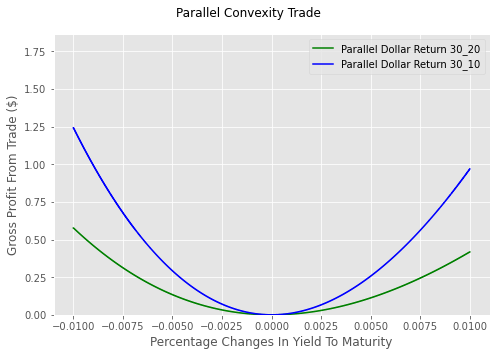

In [19]:
data=df.drop(['Non-Parallel Dollar Return 30_20',
              'Non-Parallel Dollar Return 30_10'],axis=1)
plot_trade_results(data,'Parallel Convexity Trade')

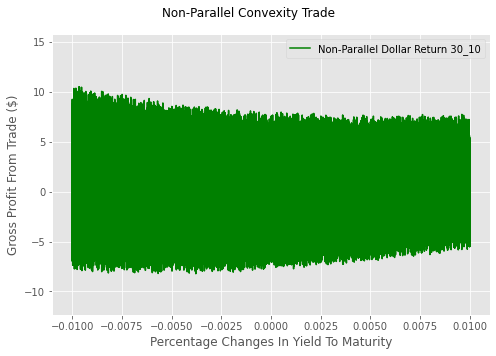

In [20]:
data=df.drop(['Parallel Dollar Return 30_20',
              'Parallel Dollar Return 30_10',
              'Non-Parallel Dollar Return 30_20'],axis=1)
plot_trade_results(data,'Non-Parallel Convexity Trade')

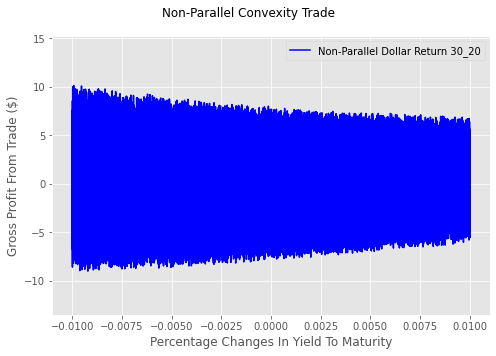

In [21]:
data=df.drop(['Parallel Dollar Return 30_20',
              'Parallel Dollar Return 30_10',
              'Non-Parallel Dollar Return 30_10'],axis=1)
plot_trade_results(data,'Non-Parallel Convexity Trade',color='blue')

## ***Summarizing***
Volatility trades are always at the forefront of traders' minds.  Convexity is understood to be synonymous with volatility.  An important concept that affects the pricing of financial instruments and motivates investment decisions.  The application, however,  requires careful thought.  Simple strategies are likely to produce unexpected results.  Here we have illustrated changes in the shape and slope of the term structure.  Changes that can significantly alter the risk-return trade-off of investment strategies that are meant to benefit from volatility or its close relative convexity.

## <font color='green'>Exercise: Graph gross profits for non-parallel convexity trades with scale factor = 0.05</font>


**Settlement date is February 3, 2026**

Show results for two trades:

*  Trade 1: Long 30-Year, Short 20-Year
*  Trade 2: Long 30-Year, Short 10-Year



<br>


 see [Chapter Eight Hints: Graph gross profits for convexity trades with scale factor = 0.05](https://colab.research.google.com/drive/1WL30MXvTfn3tTNQaaas2bmHn3G5E3lK4#scrollTo=-VjufwTN0RUr), and check the [expected results here](https://colab.research.google.com/drive/1jULdrPyul6Xs5Zrm4ysXezNNuJG7K6l6#scrollTo=kfPak5yXNMEq).


## <font color='green'>Take a deeper dive with Gemini</font>


Some suggestions to get you started.

1.  What are the risks and returns of a bond convexity trade?
2.  How long can a bond short position be held and what are the costs?
3.  What is the best type of bond to short for a convexity trade?

[Here is the link where you can copy and paste the questions](https://gemini.google.com)